In [12]:
{
    "task_name": str,
    "camera_name": str,

    "observations": np.ndarray,            # (T, 59)
    "actions": np.ndarray,                 # (T, 9)
    "rewards": np.ndarray,                 # (T,)
    "images": np.ndarray,                  # (T, H, W, 3)

    "desired_goal": dict,                  # 整个 episode 一个
    "achieved_goal": list,                 # len=T

    "step_task_completions": list,         # len=T
    "episode_task_completions": list,      # len=T
    "tasks_to_complete": list,             # len=T

    "terminated": bool,
    "truncated": bool,
    "success": bool,
    "length": int,
}

{'task_name': str,
 'camera_name': str,
 'observations': numpy.ndarray,
 'actions': numpy.ndarray,
 'rewards': numpy.ndarray,
 'images': numpy.ndarray,
 'desired_goal': dict,
 'achieved_goal': list,
 'step_task_completions': list,
 'episode_task_completions': list,
 'tasks_to_complete': list,
 'terminated': bool,
 'truncated': bool,
 'success': bool,
 'length': int}

In [9]:
import gymnasium as gym
import gymnasium_robotics

gym.register_envs(gymnasium_robotics)

env = gym.make("FrankaKitchen-v1", render_mode="rgb_array")
obs, info = env.reset()
img = env.render()
print(type(obs), img.shape)

<class 'dict'> (480, 480, 3)


In [10]:
import gymnasium as gym
import gymnasium_robotics
import numpy as np

gym.register_envs(gymnasium_robotics)

env = gym.make(
    "FrankaKitchen-v1",
    tasks_to_complete=["microwave"],
    render_mode="rgb_array"
)

obs, info = env.reset()

print("obs keys:", obs.keys())
print("observation shape:", obs["observation"].shape)
print("desired_goal:", obs["desired_goal"])
print("achieved_goal:", obs["achieved_goal"])

action = env.action_space.sample()
print("sampled action shape:", action.shape)
print("sampled action:", action)

next_obs, reward, terminated, truncated, info = env.step(action)

print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
print("info keys:", info.keys())
print("step_task_completions:", info.get("step_task_completions"))
print("episode_task_completions:", info.get("episode_task_completions"))
print("tasks_to_complete:", info.get("tasks_to_complete"))

obs keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
observation shape: (59,)
desired_goal: {'microwave': array([-0.75])}
achieved_goal: {'microwave': array([0.0010801])}
sampled action shape: (9,)
sampled action: [ 0.64956234  0.2955545   0.09140335  0.96263409 -0.64661145  0.49744615
  0.62298817  0.55755028 -0.01725075]
reward: 0.0
terminated: False
truncated: False
info keys: dict_keys(['tasks_to_complete', 'step_task_completions', 'episode_task_completions'])
step_task_completions: []
episode_task_completions: []
tasks_to_complete: ['microwave']


In [ ]:
import gymnasium as gym
import gymnasium_robotics
import numpy as np
import pickle
from pathlib import Path

gym.register_envs(gymnasium_robotics)


def make_env(task_name: str):
    env = gym.make(
        "FrankaKitchen-v1",
        tasks_to_complete=[task_name],
        render_mode="rgb_array",
    )
    return env


def collect_one_episode(env, task_name: str, camera_name: str = "default", max_steps: int = 280):
    obs, info = env.reset()

    # ===== 用 list 暂存每一步 =====
    observations = []
    actions = []
    rewards = []
    images = []

    achieved_goals = []
    step_task_completions = []
    episode_task_completions = []
    tasks_to_complete = []

    desired_goal = obs["desired_goal"]   # 整个 episode 通常固定，直接保存一份

    terminated = False
    truncated = False
    step_count = 0

    while not (terminated or truncated):
        # 1) 存当前 observation 和 image
        observations.append(np.asarray(obs["observation"], dtype=np.float64))
        achieved_goals.append(obs["achieved_goal"])

        img = env.render()
        images.append(np.asarray(img, dtype=np.uint8))

        # 2) 先用随机 action 占位，后面会换成 teleop / expert policy
        action = env.action_space.sample().astype(np.float32)
        action = np.clip(action, -1.0, 1.0)
        actions.append(action)

        # 3) step
        next_obs, reward, terminated, truncated, info = env.step(action)

        rewards.append(float(reward))
        step_task_completions.append(info.get("step_task_completions", []))
        episode_task_completions.append(info.get("episode_task_completions", []))
        tasks_to_complete.append(info.get("tasks_to_complete", []))

        obs = next_obs
        step_count += 1

        if step_count >= max_steps:
            # 双保险，虽然环境本身也会 truncated
            truncated = True

    # ===== 定义 success =====
    final_completed = episode_task_completions[-1] if len(episode_task_completions) > 0 else []
    success = (task_name in final_completed) or bool(terminated)

    # ===== 打包 trajectory =====
    traj = {
        "task_name": task_name,
        "camera_name": camera_name,

        "observations": np.asarray(observations),      # (T, 59)
        "actions": np.asarray(actions),                # (T, 9)
        "rewards": np.asarray(rewards),                # (T,)
        "images": np.asarray(images),                  # (T, H, W, 3)

        "desired_goal": desired_goal,                  # dict
        "achieved_goal": achieved_goals,               # len=T, 每个元素是 dict

        "step_task_completions": step_task_completions,
        "episode_task_completions": episode_task_completions,
        "tasks_to_complete": tasks_to_complete,

        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "success": bool(success),
        "length": len(actions),
    }

    return traj


def save_demo_list(demos, save_path: str):
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "wb") as f:
        pickle.dump(demos, f)
    print(f"saved {len(demos)} demos to {save_path}")


task_name = "microwave"

env = make_env(task_name)
traj = collect_one_episode(env, task_name=task_name, camera_name="default")

env.close()

print("==== collected one trajectory ====")
print("task_name:", traj["task_name"])
print("success:", traj["success"])
print("terminated:", traj["terminated"])
print("truncated:", traj["truncated"])
print("length:", traj["length"])
print("observations shape:", traj["observations"].shape)
print("actions shape:", traj["actions"].shape)
print("rewards shape:", traj["rewards"].shape)
print("images shape:", traj["images"].shape)
print("desired_goal:", traj["desired_goal"])
print("final achieved_goal:", traj["achieved_goal"][-1])
print("final episode_task_completions:", traj["episode_task_completions"][-1] if traj["length"] > 0 else [])

# 先保存成 list[traj]，和你老 demo 顶层 list 格式类似
save_demo_list([traj], f"./new_demos/{task_name}_debug.pkl")

==== collected one trajectory ====
task_name: microwave
success: False
terminated: False
truncated: True
length: 280
observations shape: (280, 59)
actions shape: (280, 9)
rewards shape: (280,)
images shape: (280, 480, 480, 3)
desired_goal: {'microwave': array([-0.75])}
final achieved_goal: {'microwave': array([-2.74363298e-17])}
final episode_task_completions: []
saved 1 demos to new_demos/microwave_debug.pkl


: 

In [1]:
import gymnasium as gym
import gymnasium_robotics

gym.register_envs(gymnasium_robotics)

env = gym.make(
    "FrankaKitchen-v1",
    tasks_to_complete=["microwave"],
    render_mode="rgb_array",
)

obs, info = env.reset()

model = env.unwrapped.model

print("ncam:", model.ncam)
print("camera names:")
for i in range(model.ncam):
    name = model.camera(i).name
    print(i, repr(name))

ncam: 2
camera names:
0 'left_cap'
1 'right_cap'


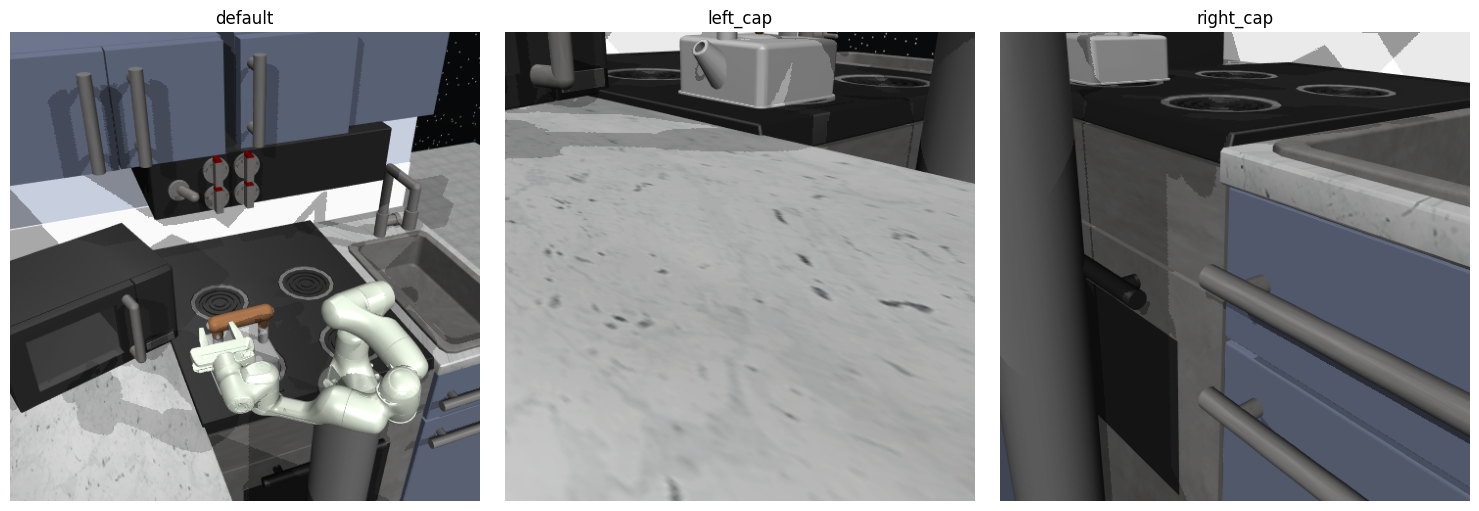

In [4]:
import gymnasium as gym
import gymnasium_robotics
import matplotlib.pyplot as plt

gym.register_envs(gymnasium_robotics)


def render_env(camera_name=None):
    base_kwargs = dict(
        tasks_to_complete=["microwave"],
        render_mode="rgb_array",
    )

    env = None
    img = None

    # 方案 1：优先尝试在 gym.make() 里传 camera_name
    try:
        if camera_name is None:
            env = gym.make("FrankaKitchen-v1", **base_kwargs)
        else:
            env = gym.make("FrankaKitchen-v1", camera_name=camera_name, **base_kwargs)

        obs, info = env.reset()
        img = env.render()
        env.close()
        return img

    except TypeError:
        # 说明这个环境构造器可能不接受 camera_name
        if env is not None:
            env.close()

    # 方案 2：先正常创建，再尝试设置 unwrapped.camera_name
    env = gym.make("FrankaKitchen-v1", **base_kwargs)
    obs, info = env.reset()

    if camera_name is not None and hasattr(env.unwrapped, "camera_name"):
        env.unwrapped.camera_name = camera_name

    img = env.render()
    env.close()
    return img


img_default = render_env(None)
img_left = render_env("left_cap")
img_right = render_env("right_cap")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_default)
plt.title("default")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_left)
plt.title("left_cap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_right)
plt.title("right_cap")
plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import gymnasium as gym
import gymnasium_robotics
import mujoco

gym.register_envs(gymnasium_robotics)

env = gym.make(
    "FrankaKitchen-v1",
    tasks_to_complete=["microwave"],
    render_mode="rgb_array",
)

obs, info = env.reset()
model = env.unwrapped.model

print("=== site names ===")
for i in range(model.nsite):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SITE, i)
    print(i, name)

print("\n=== body names ===")
for i in range(model.nbody):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, i)
    print(i, name)

env.close()

=== site names ===
0 xaxis
1 yaxis
2 end_effector
3 knob1_site
4 knob2_site
5 knob3_site
6 knob4_site
7 light_site
8 slide_site
9 hinge_site1
10 hinge_site2
11 microhandle_site
12 kettle_site

=== body names ===
0 world
1 None
2 panda0_link0
3 panda0_link1
4 panda0_link2
5 panda0_link3
6 panda0_link4
7 panda0_link5
8 panda0_link6
9 panda0_link7
10 panda0_leftfinger
11 panda0_rightfinger
12 desk
13 counters1
14 counters
15 oven
16 ovenroot
17 knob 1
18 Burner 1
19 knob 2
20 Burner 2
21 knob 3
22 Burner 3
23 knob 4
24 Burner 4
25 hoodroot
26 lightswitchbaseroot
27 lightswitchroot
28 lightblock_hinge
29 backwall
30 wallroot
31 wall2
32 slidecabinet
33 slide
34 slidelink
35 hingecabinet
36 hingecab
37 hingeleftdoor
38 hingerightdoor
39 microwave
40 microroot
41 microdoorroot
42 kettle
43 kettleroot
